# Subfigures a and b

In [ ]:
import torch
import sympy
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

import sys
sys.path.append('LoH')
from general_models import *
from experiments.generate_data import *
from utils import *


if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')


plt.rcParams.update({
    'figure.dpi': 300,
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


In [ ]:
def additional_rules(num_new_clauses, num_literals, clause_length_range, random_cnf, negated=0.5, verbose=False):
    additional_rules = []
    while num_new_clauses > 0:
        new_clauses = generate_random_list_clauses(num_new_clauses, num_literals, clause_length_range, negated=negated)
        for new_clause in new_clauses: # Check for redundant rules
            # Check if the new clause is a subset of any existing clause
            is_duplicate = False
            for existing_clause in random_cnf:
                if set(new_clause).issuperset(set(existing_clause) or set(existing_clause).issuperset(set(new_clause))):
                    is_duplicate = True
                    if verbose:
                        print("Duplicate clause: ", new_clause)
                    break
            if not is_duplicate:
                additional_rules.append(new_clause)
                num_new_clauses -= 1
                if verbose:
                    print("New clause: ", new_clause)
    return additional_rules


def evaluate_model(model, data_loader, device):
    model.eval()
    with torch.no_grad():
        outputs, predicted, labels = predict(model, data_loader, device)
        acc, f1 = eval(predicted, labels)
    model.train()
    return acc, f1

        
def train_model(model, train_loader, optimizer, n_epochs, device, 
                val_loader=None, batches_per_eval=1, verbose=True, early_stopping=False, criterion=torch.nn.BCELoss()):
    
    f1_scores_train = []
    f1_scores_val = []  
    model.to(device)
    
    model.train()
    batch = 0
    counter_no_improvement = 0
    last_f1s = [0, 0]
    stopped = False

    for epoch in range(n_epochs):
        if stopped:
            break
        for choose in model.operands:
            choose.gradients = []
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            for choose in model.operands:
                choose.gradients.append(choose.Z.grad[0].item())
            optimizer.step()
        
            batch += 1
            if batch % batches_per_eval == 0:
                print(f"Epoch {epoch+1}/{n_epochs}, Batch {batch} - Loss: {loss.item():.6f}")

                acc_train, f1_train = evaluate_model(model, train_loader, device)
                acc_val, f1_val = evaluate_model(model, val_loader, device) if val_loader else (None, None)
                f1_scores_train.append(f1_train)
                f1_scores_val.append(f1_val)

                print(f"\t Train Acc: {acc_train:.2f}, Train F1: {f1_train:.4f}")
                print(f"\t Val Acc: {acc_val:.2f}, Val F1: {f1_val:.4f}")

                if verbose:
                    #print(f"Train Loss: {loss.item():.6f}")
                    formula = model.extract_formula()
                    print("Formula: ", formula)
                    simplified_formula = sympy.parse_expr(formula)
                    print("Simplified formula: ", simplified_formula)

                    print("Weights: ")
                    for i, choose in enumerate(model.operands):
                        print(f"{i}  weight: {choose.get_weights()[0].item():.3f}  gradient: {choose.gradients} \t {choose}")
            
            if f1_val == last_f1s[0] and f1_train == last_f1s[1]:
                counter_no_improvement += 1
            else:
                counter_no_improvement = 0
                last_f1s = [f1_val, f1_train]

            if early_stopping and ((f1_train > 0.999 or f1_val > 0.999) or counter_no_improvement > 63):
                print("Early stopping at epoch ", epoch)
                stopped = True
                break
            
    return f1_scores_train, f1_scores_val


def experiment(rules, proposition_names, conjunction=True, fixed_length_model = False,
                lr=0.15, n_epochs=15, repetitions=20, verbose=False, baches_per_eval=1, early_stopping=True, 
                choosedual=True, criterion=torch.nn.BCELoss()):
    
    global train_loader, test_loader
    global device
    
    f1_train = []
    f1_val = []

    for i in range(repetitions):
        print(f"Repetition {i+1}/{repetitions}")
        if not fixed_length_model:
            model = select_rules_architecture(rules, proposition_names, conjunction=conjunction, choosedual=choosedual).to(device)
        else:
            list_oracles = [rules for _ in range(fixed_length_model)]
            model = select_one_rule_per_list_architecture(list_oracles, proposition_names, conjunction=conjunction, choosedual=choosedual).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        print("Model: ", model)
        print()
        f1_scores_train, f1_scores_val = train_model(model, train_loader, optimizer, n_epochs, device, val_loader=test_loader, 
                                                     verbose=verbose, early_stopping=early_stopping, batches_per_eval=baches_per_eval,
                                                     criterion=criterion)
        f1_train.append(f1_scores_train)
        f1_val.append(f1_scores_val)
        print("----------------------------------------------------------")
        print()
        
    # fill in the missing values with last value
    max_length = max(len(f1) for f1 in f1_train)
    for i in range(repetitions):
        while len(f1_train[i]) < max_length:
            f1_train[i].append(f1_train[i][-1])
            f1_val[i].append(f1_val[i][-1])

    f1_train = np.array(f1_train)
    f1_val = np.array(f1_val)
        
    return model, f1_train, f1_val


In [ ]:
batch_size = 128
repetitions = 15
batches_per_eval = 1
lr = 0.15
experiment_models = {}
experiment_models2 = {}

In [ ]:
proportion_true_clauses = 1.
clause_length_range = (2, 5)
choosedual = True
cnf = True
conjunction_between_rules = True if cnf else False
formula_type = 'cnf' if cnf else 'dnf'

for rep in range(repetitions):
    print("!!!!!!!!!!!!!!!!!!!!!!!!!")
    print("Repetition: ", rep)
    print()
    for num_literals in [10]:
        n_epochs = 64 // 2**(num_literals-10)
        for num_clauses in [5, 10, 15, 20]:
            proposition_names = [f"P_{i+1}" for i in range(num_literals)]
            random_cnf = generate_random_list_clauses(num_clauses, num_literals, clause_length_range, negated=0.5)
            named_list, named_strs, named_str = assign_proposition_names(random_cnf, proposition_names, cnf=cnf)
            assignments = generate_all_assignments(num_literals)
            results = evaluate_formula(assignments, random_cnf, formula_type=formula_type)
            #  Split the dataset into training and validation sets
            X_train, X_test, y_train, y_test = train_test_split(assignments + 0., results + 0., test_size=0.25, random_state=42)
            #print(X_train.shape, y_train.shape)
            # Data loaders
            train_dataset =  TensorDataset(X_train, y_train)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
            test_dataset = TensorDataset(X_test, y_test)
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
            kept_rules = named_strs[:int(num_clauses * proportion_true_clauses)]
            for num_new_clauses in [10, 17, 24, 31]:
                additional_rules_ = additional_rules(num_new_clauses, num_literals, clause_length_range, random_cnf, negated=0.5)
                additional_rules_named, additional_rules_strs, additional_rules_str = assign_proposition_names(additional_rules_, proposition_names, cnf=cnf)
                all_rules = kept_rules + additional_rules_strs
                print(rep, num_clauses, num_new_clauses, clause_length_range, num_literals, proportion_true_clauses)
                print("Solution: \t \t ", named_str)
                print("Rules: \t \t ", all_rules)
                proportion_true_labels = 100*torch.sum(results).item() / len(results)
                print(f"Proportion true labels:   {proportion_true_labels:.1f} %")
                print()
                rules = kept_rules + additional_rules_strs
                result = experiment(all_rules, 
                                    proposition_names=proposition_names, conjunction=conjunction_between_rules,
                                    lr=lr, n_epochs=n_epochs, repetitions=1, 
                                    verbose=False, baches_per_eval=batches_per_eval, early_stopping=True, 
                                    choosedual=choosedual)
                if (num_clauses, num_new_clauses) in experiment_models2:
                    experiment_models2[(num_clauses, num_new_clauses)].append((result[1], result[2], proportion_true_labels))
                else:
                    experiment_models2[(num_clauses, num_new_clauses)] = [(result[1], result[2], proportion_true_labels)]

!!!!!!!!!!!!!!!!!!!!!!!!!
Repetition:  0

0 5 10 (2, 5) 10 1.0
Solution: 	 	  (~P_9 | P_1 | ~P_2 | ~P_7 | ~P_10) & (~P_9 | ~P_6 | P_7) & (P_7 | P_8 | ~P_1) & (~P_4 | ~P_10 | ~P_1 | ~P_3) & (P_6 | ~P_3)
Rules: 	 	  ['(~P_9 | P_1 | ~P_2 | ~P_7 | ~P_10)', '(~P_9 | ~P_6 | P_7)', '(P_7 | P_8 | ~P_1)', '(~P_4 | ~P_10 | ~P_1 | ~P_3)', '(P_6 | ~P_3)', '(P_4 | P_8)', '(~P_2 | P_8 | ~P_9)', '(P_2 | ~P_1 | P_8)', '(P_2 | ~P_8)', '(~P_3 | P_1)', '(~P_1 | ~P_4)', '(P_9 | ~P_5 | ~P_7 | P_4)', '(~P_1 | P_9 | P_6)', '(~P_9 | ~P_8 | P_5 | P_2)', '(P_5 | ~P_8 | P_7 | P_1)']
Proportion true labels:   52.0 %

Repetition 1/1
Model:  ([(~ P_9 | P_1 | ~ P_2 | ~ P_7 | ~ P_10), True]_ & [(~ P_9 | ~ P_6 | P_7), True]_ & [(P_7 | P_8 | ~ P_1), True]_ & [(~ P_4 | ~ P_10 | ~ P_1 | ~ P_3), True]_ & [(P_6 | ~ P_3), True]_ & [(P_4 | P_8), True]_ & [(~ P_2 | P_8 | ~ P_9), True]_ & [(P_2 | ~ P_1 | P_8), True]_ & [(P_2 | ~ P_8), True]_ & [(~ P_3 | P_1), True]_ & [(~ P_1 | ~ P_4), True]_ & [(P_9 | ~ P_5 | ~ P_7 | P_4), Tr

In [ ]:
# Save the dictionary
with open('LoH/experiments/results/experiment_models_proportion-1_lengths-2-5_dual.pickle', 'wb') as f:
    pickle.dump(experiment_models2, f)

In [ ]:
# Load the dictionary
with open('LoH/experiments/results/experiment_models_proportion-1_lengths-2-5_dual.pickle', 'rb') as f:
    experiment_models2 = pickle.load(f)

In [6]:
experiment_results = {}
for model, list_ in experiment_models.items():
    if model not in experiment_results:
        experiment_results[model] = []
    for i in range(len(list_)):
        experiment_results[model].append([list_[i][0][0][-1], list_[i][1][0][-1], len(list_[i][0][0]), list_[i][2]])

experiment_results

{(5, 10): [[0.9947712418300654, 1.0, 42, 47.265625],
  [0.9741525446245902, 0.9715261778024946, 99, 60.15625],
  [1.0, 1.0, 11, 58.7890625],
  [0.972535135715052, 0.9803605677023399, 81, 47.265625],
  [1.0, 1.0, 10, 42.96875],
  [0.9541921509750357, 0.9565479037758267, 144, 56.25],
  [0.9546780305401118, 0.951707225051877, 180, 61.71875],
  [0.9709267110841915, 0.9649794801641587, 80, 35.15625],
  [1.0, 1.0, 21, 73.2421875],
  [0.9822744582826606, 0.9797874524294534, 99, 40.625]],
 (5, 17): [[1.0, 1.0, 12, 47.265625],
  [1.0, 1.0, 33, 60.15625],
  [1.0, 1.0, 7, 58.7890625],
  [1.0, 1.0, 43, 47.265625],
  [0.9814435124779952, 1.0, 72, 42.96875],
  [0.9907777024882706, 0.9960104103355307, 86, 56.25],
  [1.0, 1.0, 6, 61.71875],
  [1.0, 1.0, 54, 35.15625],
  [0.9508301338912306, 0.9295555025591165, 98, 73.2421875],
  [0.9945734736128089, 1.0, 44, 40.625]],
 (5, 24): [[0.9960790653744374, 0.988240878259405, 132, 47.265625],
  [0.957091492371881, 0.9283916083916084, 172, 60.15625],
  [0.9690

In [7]:
experiment_results2 = {}
for model, list_ in experiment_models2.items():
    if model not in experiment_results2:
        experiment_results2[model] = []
    for i in range(len(list_)):
        experiment_results2[model].append([list_[i][0][0][-1], list_[i][1][0][-1], len(list_[i][0][0]), list_[i][2]])

experiment_results2

{(5, 10): [[1.0, 1.0, 3, 51.953125],
  [1.0, 1.0, 17, 35.15625],
  [1.0, 1.0, 3, 39.84375],
  [1.0, 1.0, 3, 65.33203125],
  [1.0, 1.0, 26, 51.5625],
  [1.0, 1.0, 11, 54.6875],
  [1.0, 1.0, 1, 54.6875],
  [0.9781965293303524, 1.0, 10, 39.84375],
  [1.0, 1.0, 1, 73.6328125],
  [1.0, 1.0, 18, 58.59375]],
 (5, 17): [[1.0, 1.0, 21, 51.953125],
  [1.0, 1.0, 30, 35.15625],
  [1.0, 1.0, 33, 39.84375],
  [1.0, 1.0, 3, 65.33203125],
  [1.0, 1.0, 13, 51.5625],
  [1.0, 1.0, 14, 54.6875],
  [1.0, 1.0, 2, 54.6875],
  [1.0, 1.0, 26, 39.84375],
  [1.0, 1.0, 3, 73.6328125],
  [1.0, 1.0, 9, 58.59375]],
 (5, 24): [[1.0, 1.0, 1, 51.953125],
  [1.0, 1.0, 58, 35.15625],
  [0.9945553539019965, 1.0, 17, 39.84375],
  [1.0, 1.0, 3, 65.33203125],
  [1.0, 1.0, 7, 51.5625],
  [1.0, 1.0, 15, 54.6875],
  [1.0, 1.0, 25, 54.6875],
  [1.0, 1.0, 30, 39.84375],
  [1.0, 1.0, 14, 73.6328125],
  [1.0, 1.0, 9, 58.59375]],
 (5, 31): [[1.0, 1.0, 11, 51.953125],
  [1.0, 1.0, 30, 35.15625],
  [1.0, 1.0, 28, 39.84375],
  [1.0, 1.

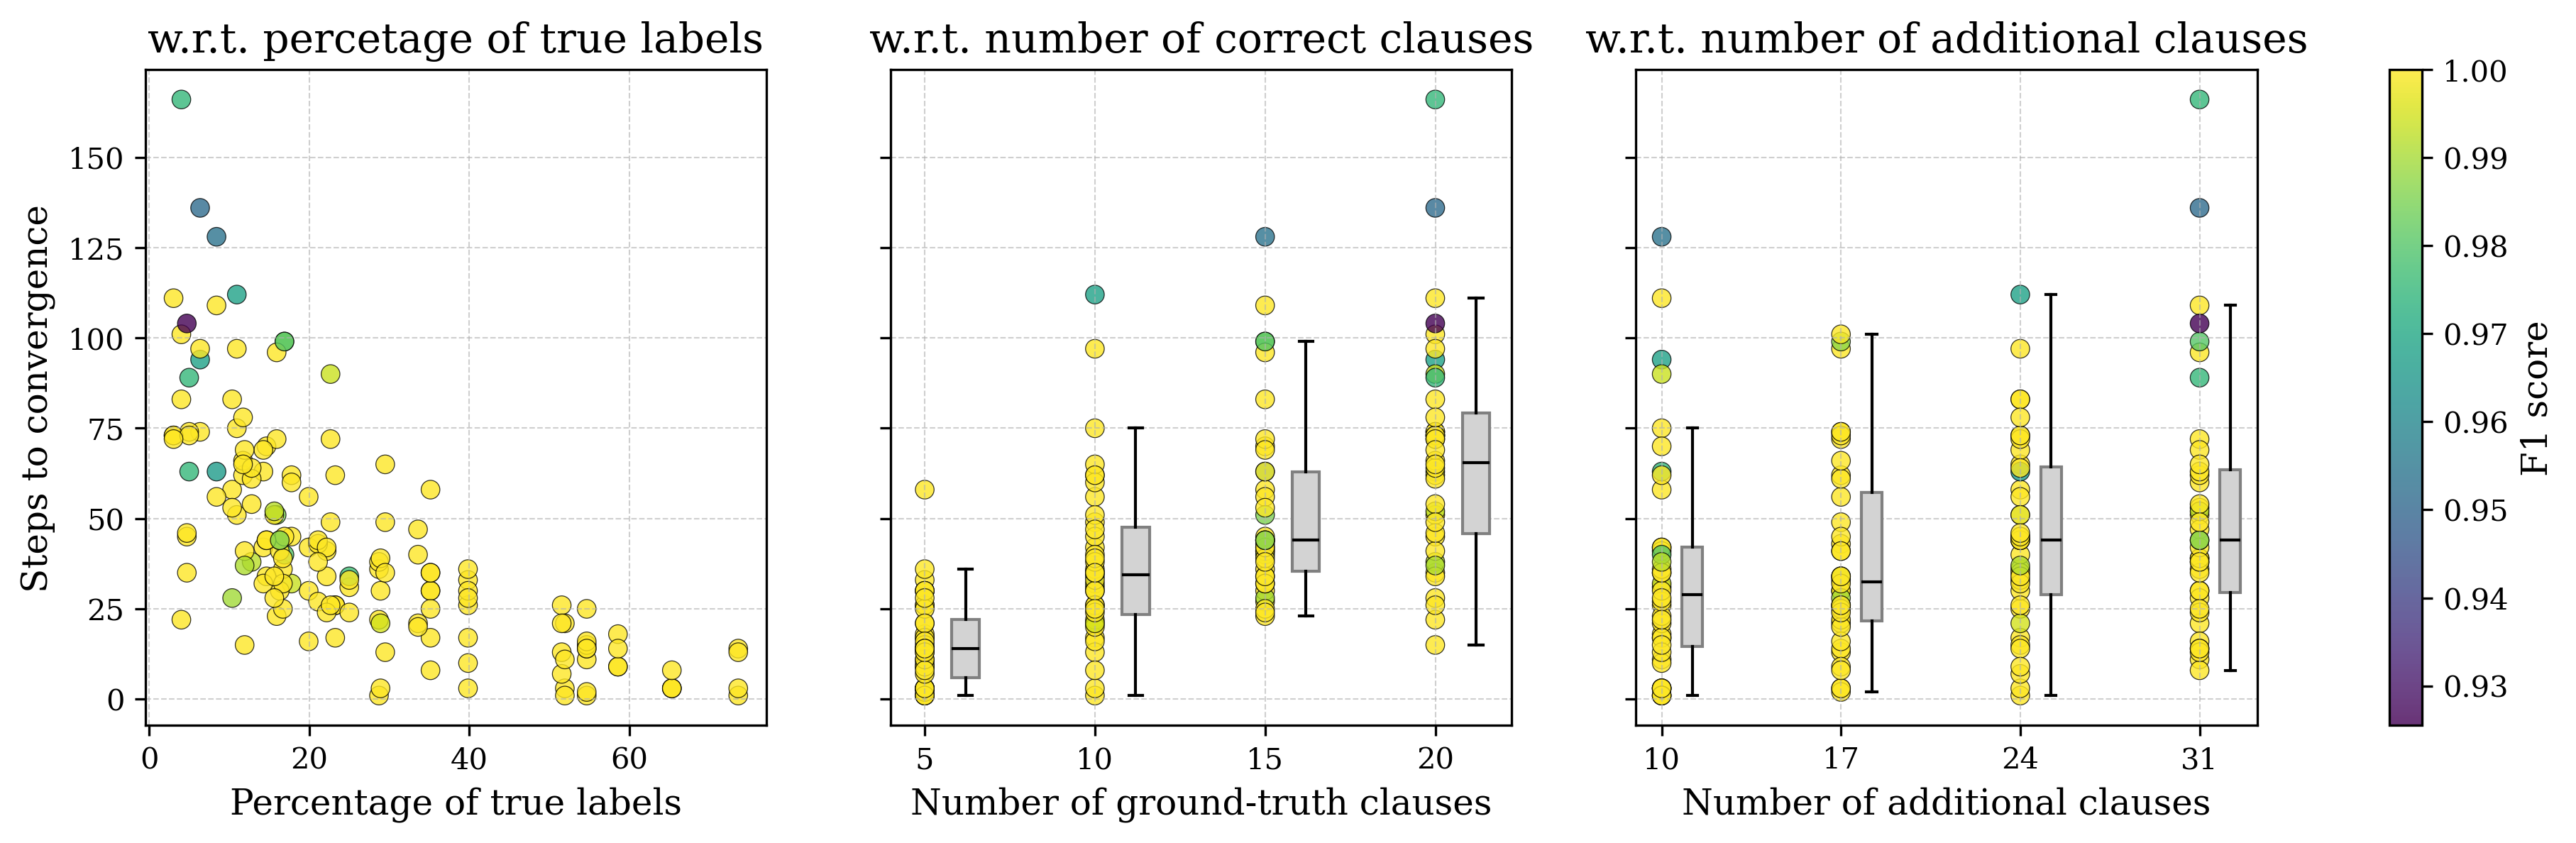

In [12]:
x_sum, x_k0, x_k1 = [], [], []
y_vals, colors, proportions = [], [], []

for key, value_list in experiment_results2.items():
    k0, k1 = key
    for item in value_list:
        x_sum.append(k0 + k1)
        x_k0.append(k0)
        x_k1.append(k1)
        y_vals.append(item[2])
        colors.append(item[1])
        proportions.append(item[3])

colors = np.array(colors)
proportions = np.array(proportions)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Scatter 1
sc1 = axs[0].scatter(proportions, y_vals, c=colors, cmap='viridis', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
axs[0].set_title('w.r.t. percetage of true labels')
axs[0].set_xlabel('Percentage of true labels')
axs[0].set_ylabel('Steps to convergence')
axs[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Scatter 2 + boxplot
sc2 = axs[1].scatter(x_k0, y_vals, c=colors, cmap='viridis', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
axs[1].set_title('w.r.t. number of correct clauses')
axs[1].set_xlabel('Number of ground-truth clauses')

# Prepare boxplot data for x_k0
box_data_k0 = defaultdict(list)
for x, y in zip(x_k0, y_vals):
    box_data_k0[x].append(y)

# Offset for boxplot (slightly to the right)
offset = 1.2
positions_k0 = [x + offset for x in box_data_k0.keys()]
box_values_k0 = [box_data_k0[x] for x in box_data_k0]

axs[1].boxplot(box_values_k0, positions=positions_k0, widths=0.8, patch_artist=True,
               boxprops=dict(facecolor='lightgray', color='gray'),
               medianprops=dict(color='black'), showfliers=False)

axs[1].set_xticks(sorted(box_data_k0.keys()))
axs[1].set_xticklabels(sorted(box_data_k0.keys()))
axs[1].set_xlim(min(x_k0) - 1, max(x_k0) + 2.25)
axs[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


# Scatter 3 + boxplot
offset = 1.2
sc3 = axs[2].scatter(x_k1, y_vals, c=colors, cmap='viridis', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
axs[2].set_title('w.r.t. number of additional clauses')
axs[2].set_xlabel('Number of additional clauses')

# Prepare boxplot data for x_k1
box_data_k1 = defaultdict(list)
for x, y in zip(x_k1, y_vals):
    box_data_k1[x].append(y)

positions_k1 = [x + offset for x in box_data_k1.keys()]
box_values_k1 = [box_data_k1[x] for x in box_data_k1]

axs[2].boxplot(box_values_k1, positions=positions_k1, widths=0.8, patch_artist=True,
               boxprops=dict(facecolor='lightgray', color='gray'),
               medianprops=dict(color='black'), showfliers=False)

axs[2].set_xticks(sorted(box_data_k1.keys()))
axs[2].set_xticklabels(sorted(box_data_k1.keys()))
axs[2].set_xlim(min(x_k1) - 1, max(x_k1) + 2.25)
axs[2].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Colorbar
fig.colorbar(sc1, ax=axs, orientation='vertical', label='F1 score')
plt.savefig('fig_cnf.pdf', bbox_inches='tight')
plt.show()

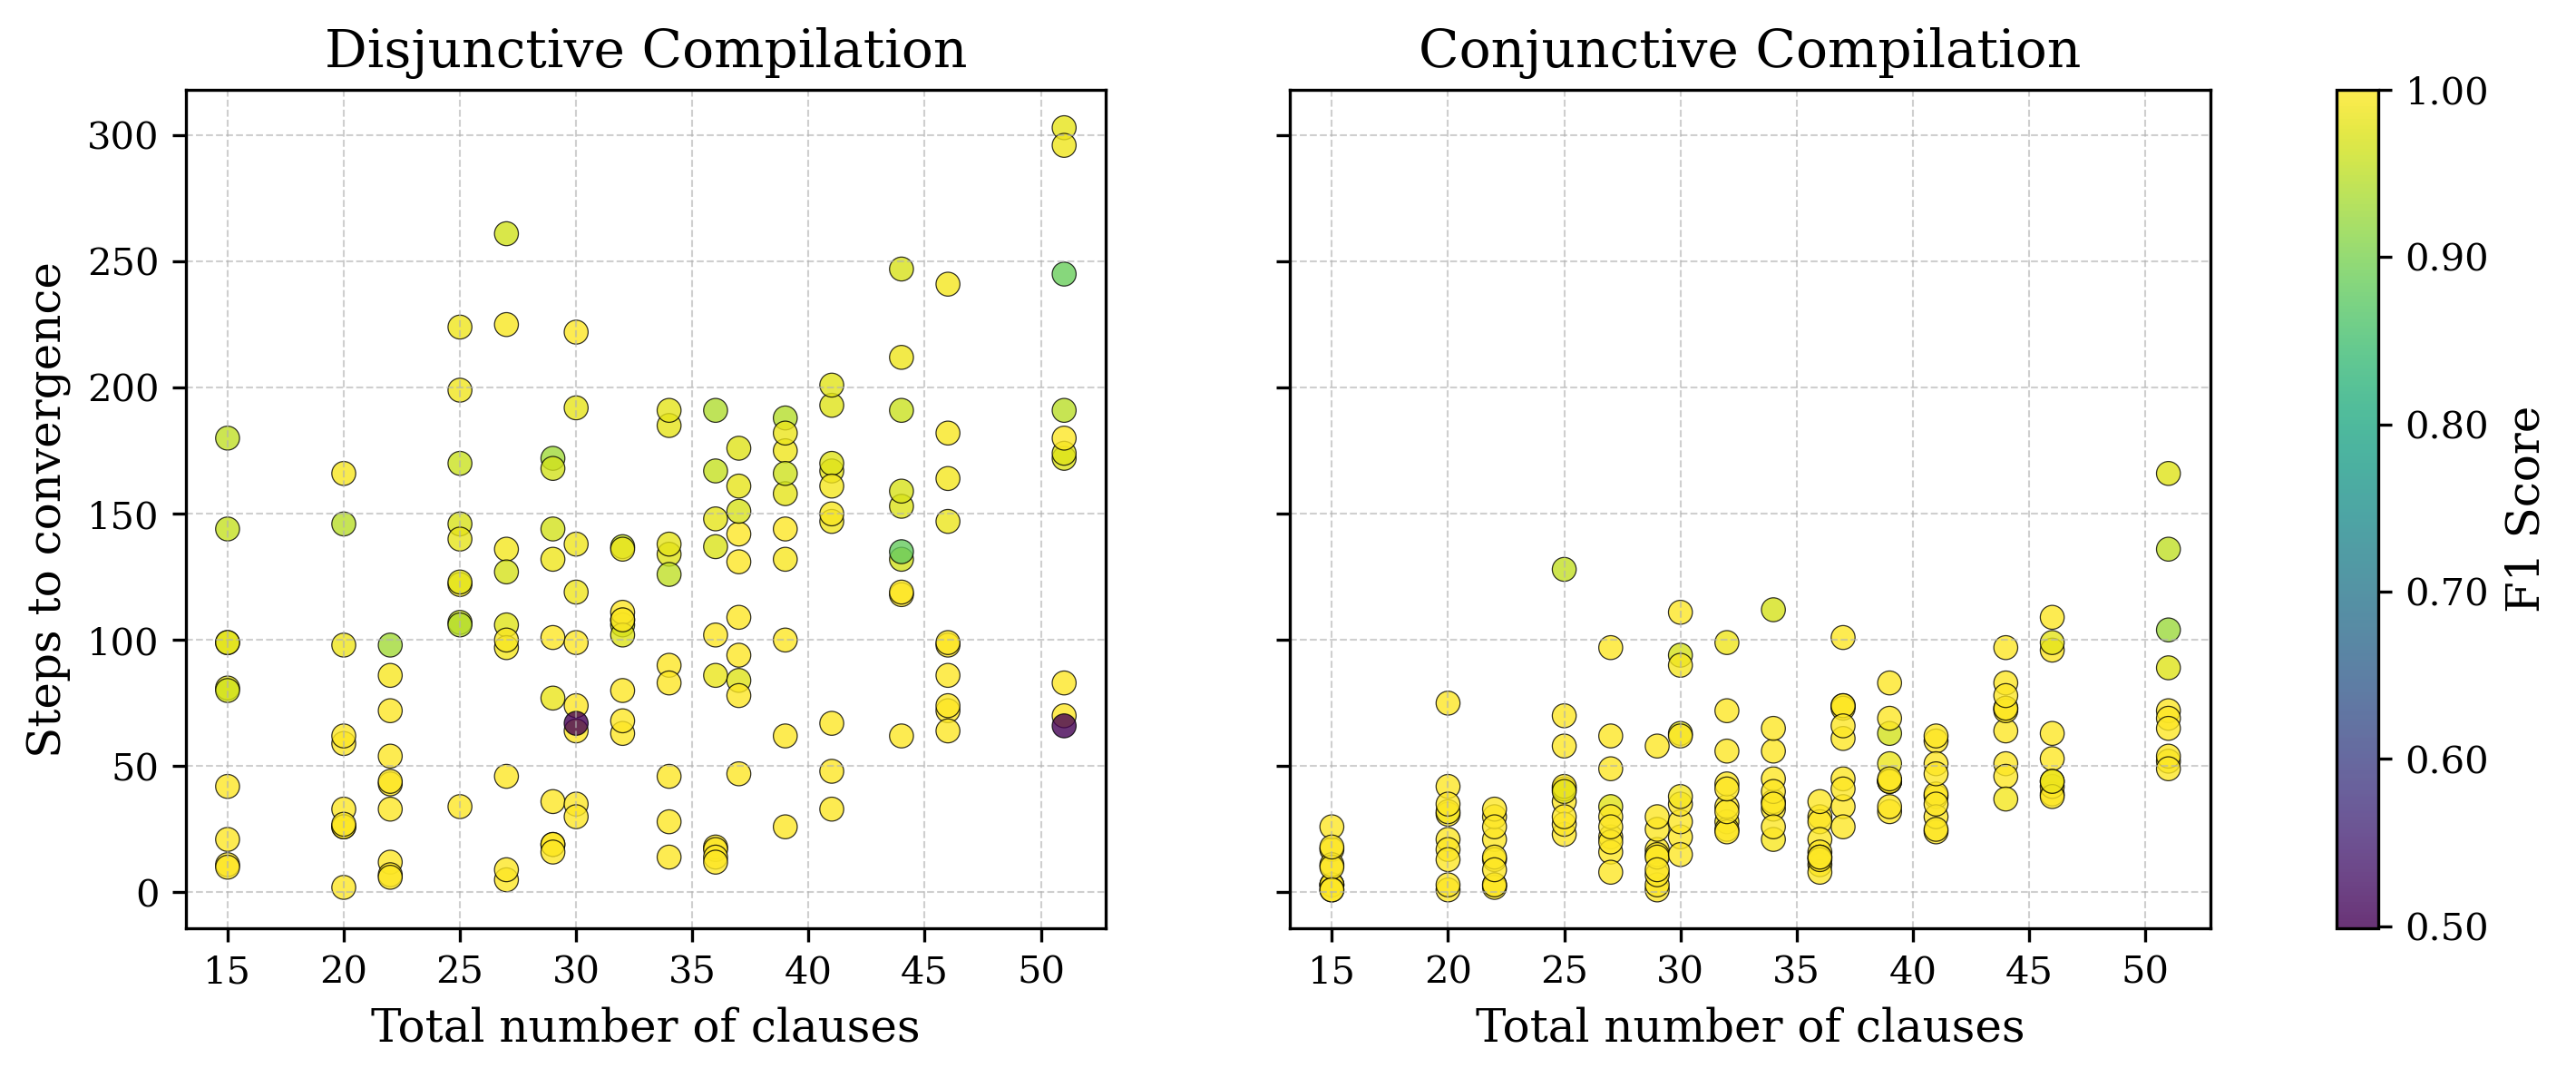

In [19]:
x_sum, x_sum2 = [], []
y_vals, y_vals2 = [], []
colors, colors2 = [], []

for key, value_list in experiment_results.items():
    x = key[0] + key[1]
    for item in value_list:
        x_sum.append(x)
        y_vals.append(item[2])
        colors.append(item[1])

for key, value_list in experiment_results2.items():
    x = key[0] + key[1]
    for item in value_list:
        x_sum2.append(x)
        y_vals2.append(item[2])  
        colors2.append(item[1])

colors = np.array(colors)
#colors_norm = (colors - colors.min()) / (colors.max() - colors.min())
colors2 = np.array(colors2)
#colors_norm2 = (colors2 - colors2.min()) / (colors2.max() - colors2.min())
vmin = min(colors.min(), colors2.min())
vmax = max(colors.max(), colors2.max())
norm = plt.Normalize(vmin=vmin, vmax=vmax)


fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sc1 = axs[0].scatter(x_sum, y_vals, c=colors, cmap='viridis', s=40, alpha=0.8, edgecolors='k', linewidth=0.3, norm=norm)
axs[0].set_title('Disjunctive Compilation')
axs[0].set_xlabel('Total number of clauses')
axs[0].set_ylabel('Steps to convergence')
axs[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

sc2 = axs[1].scatter(x_sum2, y_vals2, c=colors2, cmap='viridis', s=40, alpha=0.8, edgecolors='k', linewidth=0.3, norm=norm)
axs[1].set_title('Conjunctive Compilation')
axs[1].set_xlabel('Total number of clauses')
axs[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
#axs[1].set_ylabel('Steps to convergence')

# Colorbar
cbar = fig.colorbar(sc2, ax=axs, orientation='vertical', label='F1 Score', format='%.2f')
#cbar.set_ticks(np.linspace(vmin, vmax, 5))
#fig.suptitle('Convergence speed and F1-score wrt total number of clauses', fontsize=16)

plt.savefig('fig_disj_vs_conj-cnf.pdf', bbox_inches='tight')
plt.show()